In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [ ]:
# Data Loading
df_data = pd.read_csv('IMDb Movies India.csv.zip',compression='zip',encoding='latin-1')


In [7]:
df_data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [10]:
df_data.shape

(15509, 10)

In [ ]:
# Data Cleaning
df_data.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [12]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [13]:
df_data.duplicated().sum()

6

In [16]:
df_data.dropna(inplace=True)

In [17]:
df_data.shape

(5659, 10)

In [18]:
df_data.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [19]:
df_data.drop_duplicates(inplace=True)

In [20]:
df_data.shape

(5659, 10)

In [21]:
df_data.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [ ]:
# Data Preprocessing

In [22]:
df_data['Year'] = df_data['Year'].str.replace(r'[()]','',regex=True).astype(int)

In [23]:
df_data['Duration'] = pd.to_numeric(df_data['Duration'].str.replace('min',''))

In [25]:
df_data['Genre'] = df_data['Genre'].str.split(',')
df_data = df_data.explode('Genre')
df_data['Genre'].fillna(df_data['Genre'].mode()[0],inplace= True)

C:\Users\Urvashi\AppData\Local\Temp\ipykernel_10752\2222857351.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_data['Genre'].fillna(df_data['Genre'].mode()[0],inplace= True)


In [26]:
df_data['Votes'] = pd.to_numeric(df_data['Votes'].str.replace(',',''))

In [27]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11979 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      11979 non-null  object 
 1   Year      11979 non-null  int32  
 2   Duration  11979 non-null  int64  
 3   Genre     11979 non-null  object 
 4   Rating    11979 non-null  float64
 5   Votes     11979 non-null  int64  
 6   Director  11979 non-null  object 
 7   Actor 1   11979 non-null  object 
 8   Actor 2   11979 non-null  object 
 9   Actor 3   11979 non-null  object 
dtypes: float64(1), int32(1), int64(2), object(6)
memory usage: 982.7+ KB


In [ ]:
# Data Visualizing


<Axes: xlabel='Year', ylabel='Count'>

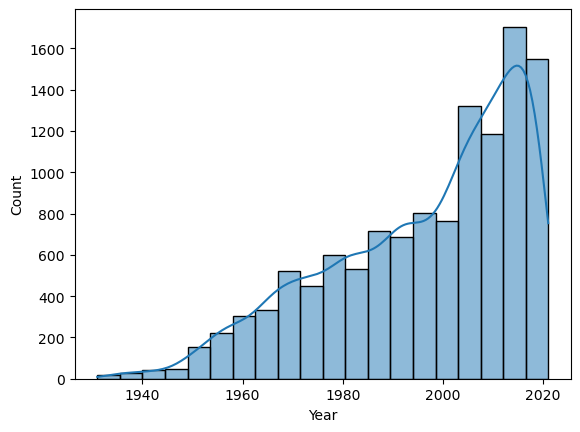

In [34]:
plt.figure(figure = (8,4))
sns.histplot(df_data['Year'],kde = True,bins = 20)

In [31]:
top_genres = df_data['Genre'].value_counts().head(10).reset_index()
top_genres.columns = ['Genre', 'Count']  # Rename the columns

import plotly.express as px

fig = px.bar(top_genres, x='Genre', y='Count',
             title='Top 10 Movie Genres by Count')
fig.show()

In [33]:
plt.figure(figure = (8,4))
avg_ratings = df_data.groupby('Year')['Rating'].mean().reset_index()

fig = px.line(avg_ratings, x='Year', y='Rating',
              title='Average Rating by Year')
fig.show()

<Figure size 640x480 with 0 Axes>

In [40]:



fig = px.histogram(
    df_data, 
    x='Rating', 
    nbins=20, 
    histnorm='probability density', 
    marginal='box',
    title='Distribution of Movie Ratings with Density'
)


fig.show()

In [ ]:
#Feature Engineering

In [41]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score,mean_absolute_error,mean_squared_error ,r2_score

In [43]:
df_data.drop('Name',axis = 1,inplace = True)

In [44]:
genre_mean_rating = df_data.groupby('Genre')['Rating'].transform('mean')
df_data['Genre_mean_rating']= genre_mean_rating
director_mean_rating = df_data.groupby('Director')['Rating'].transform('mean')
df_data['Director_encoded'] = director_mean_rating
actor1_mean_rating = df_data.groupby('Actor 1')['Rating'].transform('mean')
df_data['Actor1_encoded'] = actor1_mean_rating
actor2_mean_rating = df_data.groupby('Actor 2')['Rating'].transform('mean')
df_data['Actor2_encoded'] = actor2_mean_rating
actor3_mean_rating = df_data.groupby('Actor 3')['Rating'].transform('mean')
df_data['Actor3_encoded'] = actor3_mean_rating






In [46]:
X = df_data[['Year','Votes','Duration','Genre_mean_rating','Director_encoded','Actor1_encoded','Actor2_encoded','Actor3_encoded']]
y = df_data['Rating']

In [48]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [ ]:
#Model Buliding

In [73]:
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()

df_data['Genre'] = label.fit_transform(df_data['Genre'].astype(str))
df_data['Director'] = label.fit_transform(df_data['Director'].astype(str))



In [75]:
print('The parformance evaluation of Logistic regression is below: ','\n')
print('Mean squared error:',mean_squared_error(y_test,Model_pred))
print('Mean absolute error: ',mean_absolute_error(y_test,Model_pred))
print('R2 score:',r2_score(y_test,Model_pred))

The parformance evaluation of Logistic regression is below:  

Mean squared error: 0.4463977880886115
Mean absolute error:  0.4921055068501126
R2 score: 0.7641906900948995


In [ ]:
# Model Testing

In [51]:
X.head(5)

,Year,Votes,Duration,Genre_mean_rating,Director_encoded,Actor1_encoded,Actor2_encoded,Actor3_encoded
1,2019,8,109,6.248697,7.000000,6.850000,7.00,7.00
3,2019,35,110,5.838423,4.400000,5.250000,4.40,4.46
3,2019,35,110,5.838739,4.400000,5.250000,4.40,4.46
5,1997,827,147,5.838423,5.335135,4.793617,5.73,5.93
5,1997,827,147,5.875793,5.335135,4.793617,5.73,5.93


In [52]:
y.head(5)

1    7.0
3    4.4
3    4.4
5    4.7
5    4.7
Name: Rating, dtype: float64

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

X = df_data[['Votes', 'Year', 'Duration','Genre','Director']]
y = df_data['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Model = RandomForestRegressor()
Model.fit(X_train, y_train)

y_pred = Model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("R2 Score:",round(r2,3))

R2 Score: 0.692


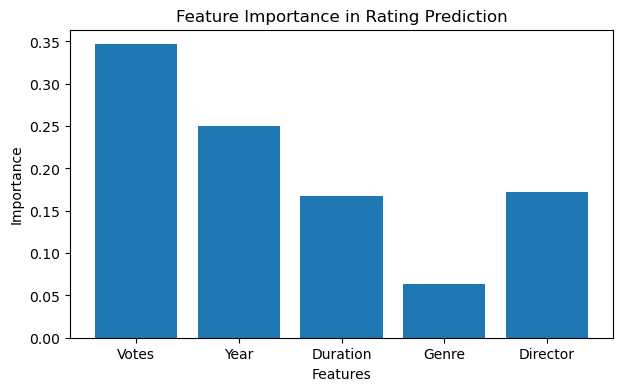

In [ ]:
# Feature Importance Plot
import matplotlib.pyplot as plt
import numpy as np

# Feature Importance
importances = Model.feature_importances_
features = X.columns

plt.figure(figsize=(7,4))
plt.bar(features, importances)
plt.title("Feature Importance in Rating Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

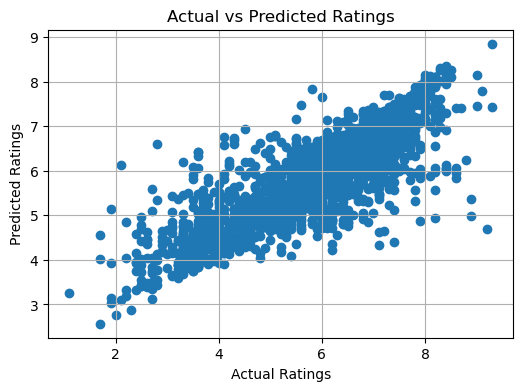

In [ ]:
# Actual vs Predicted Scatter Plot
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.grid(True)
plt.show()

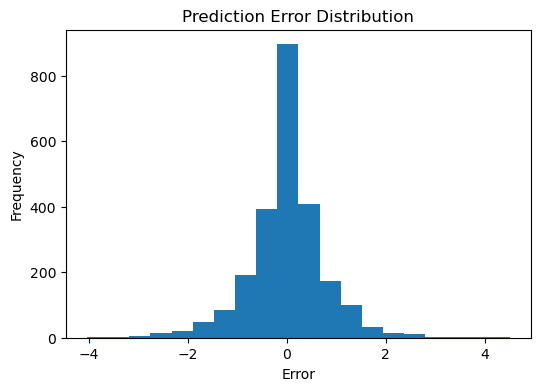

In [ ]:
# Error Distribution
errors = y_test - y_pred
plt.figure(figsize=(6,4))
plt.hist(errors, bins=20)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()